# Week 1 : Non-ideal MHD collapses with RAMSES

This notebook is just a guide to run simulations with the proper version of ramses. We strongly encourage the reader to first follow the ramses tutorials at the following link : https://ramses-tutorials.readthedocs.io/en/latest/. In particular the reader should follow the RAMSES fundamentals as well as the dense core collapse tutorial. 

Note that in this school, we are not using the main version of ramses as it does not (yet) includes all the physical processes that we would like to use. Instead the reader should clone this version (https://github.com/tinecolman/ramses) and checkout to the combo_nimhd_fld branch. This branch includes the non-ideal MHD (or at least the Ohmic dissipation and ambipolar diffusion) as well as the radiative transfer in the FLD approximation.

Namelists to run basic collapses can be found in the week 1 folder.

You will also need the resnh.dat table that contains the resistivity table, it can be found in the week 1 folder. 


As for the ramses collapse tutorial, you can use this function to compute your initial box size

In [14]:
import numpy as np

def setup_nml(alpha_dense_core=0.1,mass_c=1.,T_eos=10,tout=(0,1)):
    '''
    alpha_dense_core  : cloud virial parameter, thermal-to-gravitational energy
    mass_c            : cloud mass in solar mass
    T_eos             : cloud temperature

    tout              : output times in free-fall time units
    '''

    mH    = 1.66e-24      # H atom mass [g] = amu, i.e. atomic mass unit; NIST
    kB    = 1.38e-16      # Boltzmann const. [erg K-1]; SI
    M_sun = 2e+33 # Solar Mass [g]; IAU

    pc2cm   = 3.08e+18  # pc [cm]
    kyr2sec = 3.15576000e+10 # Kyr [s]

    G=6.67e-8 # Gravitational constant in cgs [cm3 g-1 s-2]

    mu_gas=2.31           # Mean molecular weigth

    units_length=pc2cm                      # 1 pc in cm
    units_density=mu_gas*mH                 # so that density in code units is equals to density in part/cc
    units_time=1./np.sqrt(G*units_density)  # so that G=1 in code units

    scale_d = units_density
    scale_t = units_time
    scale_l = units_length
    scale_m=scale_d*scale_l**3

    mass_c_cu = mass_c * (M_sun / scale_m ) # cloud mass in code units

    r0=(alpha_dense_core*2.*G*mass_c_cu*scale_m*mu_gas*mH/(5.*kB*T_eos))/scale_l
    boxlen=4*r0
    d0=3.0*mass_c_cu/(4.0e0*np.pi*r0**3.)

    tff=np.sqrt(3*np.pi/(32*G*d0*scale_d))/scale_t

    print('Cloud size in code units, and in pc=',r0,r0*scale_l/3.08e+18)
    print('  box size in code units, and in pc=',boxlen,boxlen*scale_l/3.08e+18)
    print('Free-fall time in code units, and in kyr=',tff,tff*scale_t/3.15576000e+10)
    print()
    print('Values to be put in the namelist')
    print('In UNITS_PARAMS')
    print('   units_density=',units_density)
    print('   units_length=',units_length)
    print('   units_time=',units_time)
    print('In AMR_PARAMS')
    print('   boxlen=',boxlen)
    print('In OUTPUT_PARAMS')
    print('   tout=', ', '.join(str(t*tff) for t in tout))
    print('Resolution at level 14 [in au]')
    print('   dx_14=',boxlen/2**15*pc2cm/1.5e13)  

In [15]:
setup_nml(alpha_dense_core=0.4,mass_c=1.,T_eos=10,tout=(0,1))

Cloud size in code units, and in pc= 0.019256000000000002 0.019256000000000002
  box size in code units, and in pc= 0.07702400000000001 0.07702400000000001
Free-fall time in code units, and in kyr= 0.0007024656718921366 44.01474478361897

Values to be put in the namelist
In UNITS_PARAMS
   units_density= 3.8346e-24
   units_length= 3.08e+18
   units_time= 1977320409468798.2
In AMR_PARAMS
   boxlen= 0.07702400000000001
In OUTPUT_PARAMS
   tout= 0.0, 0.0007024656718921366
Resolution at level 14 in au
   dx_14= 0.4826536458333334


# Visualisation

This is a quick visualisation tool. You can run the 3d collapses for a while to rediscover how disk were heroically saved by non-ideal MHD effects after being viciously killed by ideal MHD :). Try to reach at least output 5 for the hydro, output 13 for the imhd and output ?? for nimhd. You will notice that, as you include more and more physics, the simulation takes longer to run to completion.

In [ ]:
!pip install osyris

In [19]:
import osyris

Processing 4 files in collapse_hydro/output_00005
 25% : read     110595 cells,          0 particles
 50% : read     209045 cells,          0 particles
 75% : read     319628 cells,          0 particles
Loaded: 418090 cells, 0 particles.


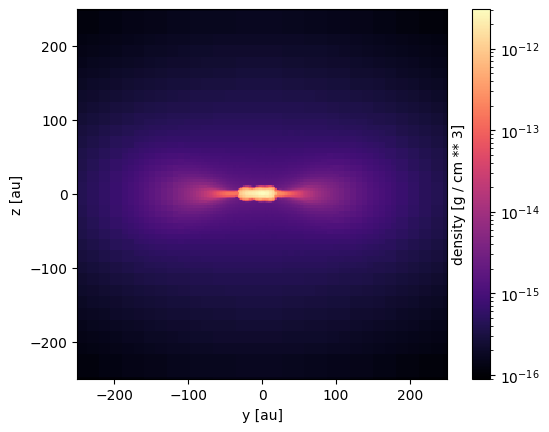

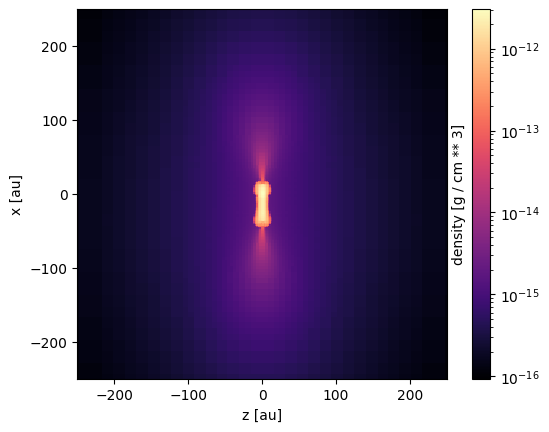

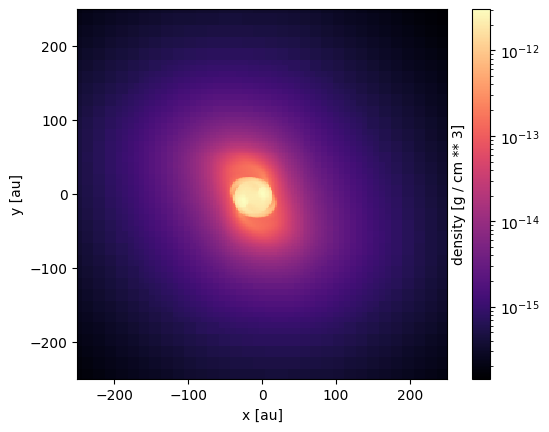

In [40]:
path_model = 'collapse_hydro'
import osyris
import numpy as np
au = osyris.units("au")
data = osyris.RamsesDataset(-1, path=path_model).load() # Change this path to the path of the model
# We find the center according to the density
ind = np.argmax(data["mesh"]["density"])
center = data["mesh"]["position"][ind]
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="x",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="y",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="z",cmap ='magma'
)

Processing 4 files in collapse_imhd/output_00013
 25% : read     105713 cells,          0 particles
 50% : read     204684 cells,          0 particles
 75% : read     310397 cells,          0 particles
Loaded: 409368 cells, 0 particles.


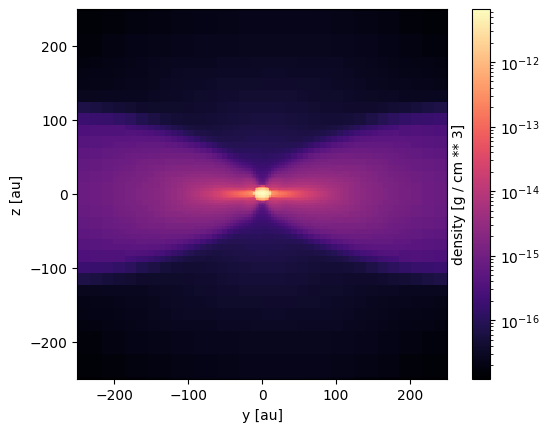

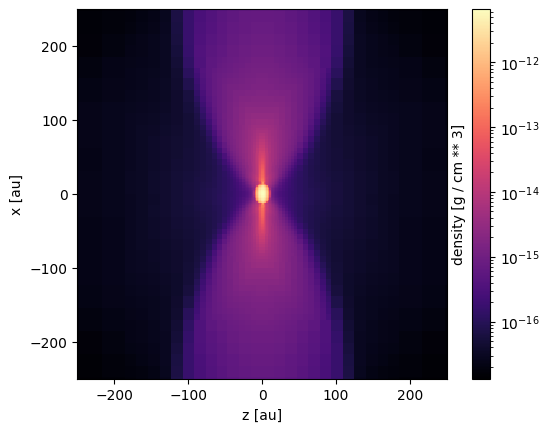

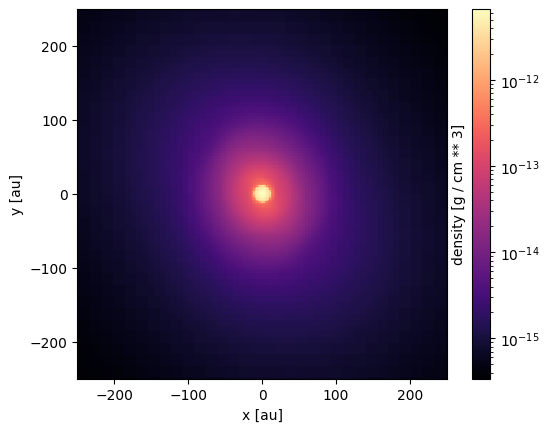

In [62]:
path_model = 'collapse_imhd'
import osyris
import numpy as np
au = osyris.units("au")

data = osyris.RamsesDataset(-1, path=path_model).load() # Change this path to the path of the model
mesh = data["mesh"]

# We find the center according to the density
ind = np.argmax(data["mesh"]["density"])
center = data["mesh"]["position"][ind]
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="x",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="y",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="z",cmap ='magma'
)

Processing 4 files in collapse_nimhd/output_00030
 25% : read     108757 cells,          0 particles
 50% : read     215040 cells,          0 particles
 75% : read     323021 cells,          0 particles
Loaded: 429283 cells, 0 particles.


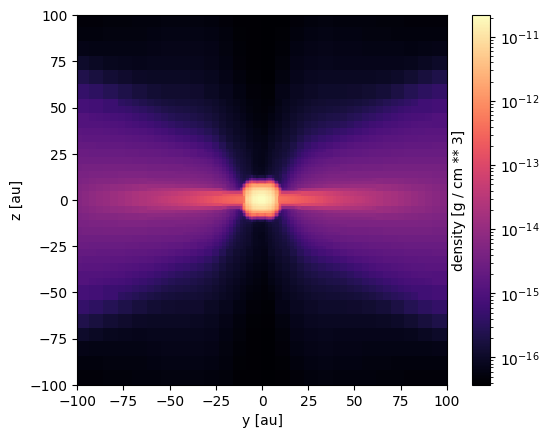

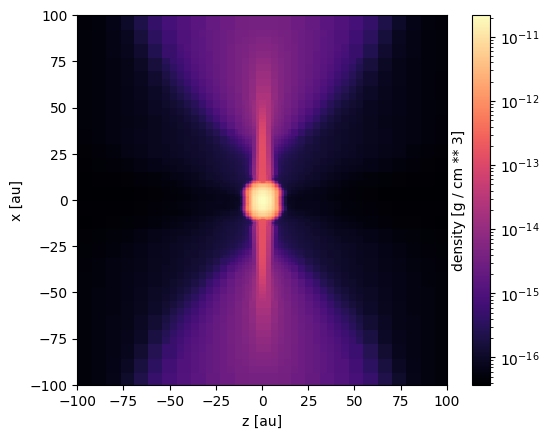

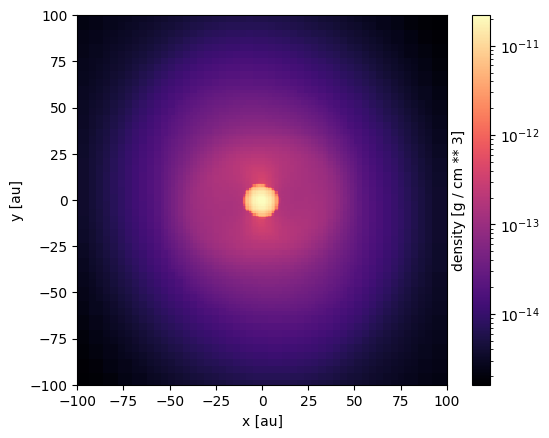

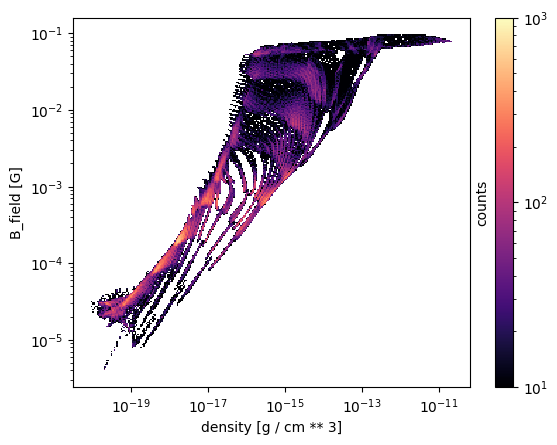

In [72]:
path_model = 'collapse_nimhd'
import osyris
import numpy as np
au = osyris.units("au")
data = osyris.RamsesDataset(-1, path=path_model).load() # Change this path to the path of the model
mesh = data["mesh"]

# We find the center according to the density
ind = np.argmax(data["mesh"]["density"])
center = data["mesh"]["position"][ind]
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=200 * au, origin=center, direction="x",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=200 * au, origin=center, direction="y",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=200 * au, origin=center, direction="z",cmap ='magma'
)

osyris.hist2d(
    mesh["density"],
    mesh["B_field"],
    norm="log",
    loglog=True,
    cmap="magma",
    vmin=10.0,
    vmax=1000.0,
)

Processing 4 files in collapse_sink/output_00009
 25% : read     121130 cells,          0 particles
 50% : read     248896 cells,          0 particles
 75% : read     357034 cells,         98 particles
Loaded: 470828 cells, 2109 particles.


'position' Min: 2.051e+17 Max: 2.051e+17 [cm] (1,), {x,y,z}

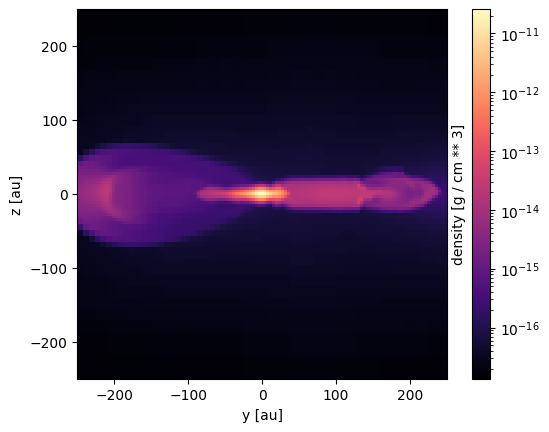

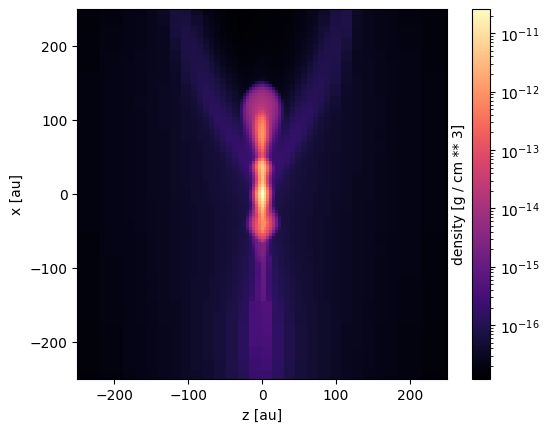

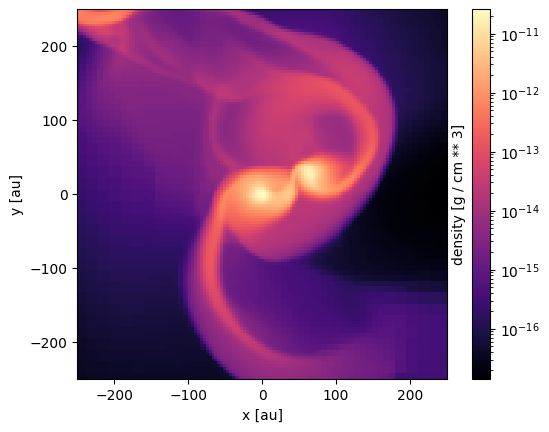

In [82]:
path_model = 'collapse_sink'
import osyris
import numpy as np
au = osyris.units("au")
data = osyris.RamsesDataset(-1, path=path_model).load() # Change this path to the path of the model
# We find the center according to the density
ind = np.argmax(data["mesh"]["density"])
center = data["mesh"]["position"][ind]
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="x",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="y",cmap ='magma'
)
osyris.map(
    data["mesh"].layer("density"), norm="log", dx=500 * au, origin=center, direction="z",cmap ='magma'
)

data["sink"]["position"]